In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score 

In [2]:
data = {
    "StudyHours":[2,3,4,5,6,7,8,3,5,6,7,8,9,4,6],
    "SleepHours":[6,7,5,6,7,8,6,7,5,6,7,8,6,7,5],
    "Attendance":[60,65,70,75,80,85,90,68,72,78,82,88,92,74,79],
    "Assignments":[50,55,60,65,70,75,80,58,62,68,72,78,82,66,70],
    "Marks":[55,60,65,70,75,80,85,62,67,73,77,83,88,69,74]
}

In [3]:
df=pd.DataFrame(data)

In [4]:
X = df[["StudyHours","SleepHours","Attendance","Assignments"]]
y = df["Marks"]

In [5]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [6]:
scaler=StandardScaler()

In [7]:
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [8]:
reg=LinearRegression()
reg.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [9]:
mse=cross_val_score(reg,X_train,y_train,cv=5,scoring="neg_mean_squared_error")

In [10]:
np.mean(mse)

np.float64(-0.3328024386552864)

In [11]:
predict_reg=reg.predict(X_test)

In [12]:
predict_reg

array([73.21363853, 83.29375298, 54.5851216 , 67.94992847])

In [13]:
y_test

9     73
11    83
0     55
13    69
Name: Marks, dtype: int64

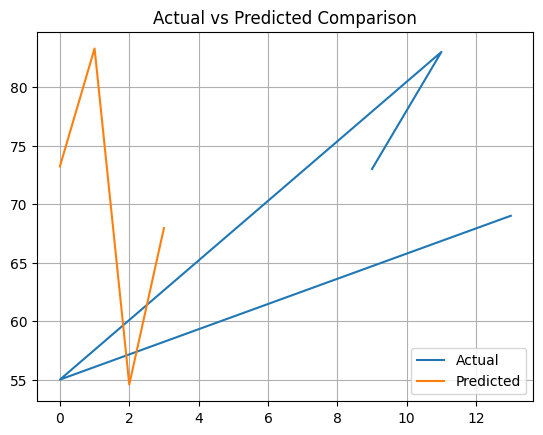

In [14]:
plt.plot(y_test, label="Actual")
plt.plot(predict_reg, label="Predicted")

plt.legend()
plt.title("Actual vs Predicted Comparison")
plt.grid()
plt.show()

In [15]:
r2 = r2_score(y_test, predict_reg) # calculate our modek accuracy 

In [16]:
r2

0.9965180531184488